# Predicting a number, not a field

Most of these tutorials end at the posterior over the parameter. A prediction is usually a
single number instead: how much power the field dissipates, how much flows past a boundary,
how hot one well gets. Call it $\mathcal{Q}$, a functional of the state and the parameter:

$$\mathcal{Q}(m) = \int_\Omega q\big(u(m), m, x\big)\,dx ,$$

with $u(m)$ the solution of the PDE. Pushing a distribution on $m$ through this map is
*forward* uncertainty propagation, and it is expensive the obvious way: every sample is a PDE
solve.

The way through is the same one the inverse problem uses. The map has adjoint derivatives, so
a quadratic model of it costs a handful of solves; the quadratic model has closed-form moments
under a Gaussian; and the difference between the map and its model is what Monte Carlo then has
to average, which is far smaller than the map itself. Here that difference buys a factor of
about a thousand, and the machinery is the same before and after the data arrive.

## 1. Load modules

In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem
import jax.numpy as jnp

import hippymfem as hm
from hippymfem import nb
from hippymfem.modeling.variables import STATE, PARAMETER, ADJOINT

## 2. The flow problem, and the number we care about

Pressure driven flow through a medium of unknown log permeability $m$, with an injection well
and a production well, and a unit pressure drop across the domain:

$$-\nabla\cdot(e^{m}\nabla u) = f,\qquad u = 1-x \ \text{ on the left and right edges}.$$

The quantity of interest is the **dissipated power**, $\int_\Omega e^{m}|\nabla u|^2$, which is
what an effective permeability is measured from. `VariationalQoi` takes it as a density, in the
same form as the residual, so its derivatives in $u$ and in $m$ are automatic.

In [2]:
comm = MPI.COMM_WORLD
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(24, 24, mfem.Element.TRIANGLE))
Vu = hm.FunctionSpace.H1(mesh, 2)
Vm = hm.FunctionSpace.H1(mesh, 1)
Vh = [Vu, Vm, Vu]
bottom, right, top, left = 1, 2, 3, 4


def wells(x):
    return 6.0 * (jnp.exp(-60.0 * ((x[0] - 0.25) ** 2 + (x[1] - 0.7) ** 2))
                  - jnp.exp(-60.0 * ((x[0] - 0.75) ** 2 + (x[1] - 0.3) ** 2)))


def pde_varf(u, m, p, x):
    return jnp.exp(m.val) * hm.inner(u.grad, p.grad) - wells(x) * p.val


def qoi_varf(u, m, x):
    return jnp.exp(m.val) * hm.inner(u.grad, u.grad)


bc = hm.DirichletBC(Vu, lambda x: 1.0 - x[0], bdr_attributes=[left, right])
pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc.homogeneous(), is_fwd_linear=True)
pde.set_solvers(hm.LUSolver, comm)

prior = hm.BiLaplacianPrior(Vm, 0.3, 3.0, robin_bc=True, solver_type="lu")
qoi = hm.VariationalQoi(Vh, qoi_varf)
p2q = hm.Parameter2QoiMap(pde, qoi)

print("state %d dofs, parameter %d dofs" % (Vu.GlobalTrueVSize(), Vm.GlobalTrueVSize()))
print("Q at the prior mean: %.6f" % p2q.reduced_eval(prior.mean.copy()))

state 2401 dofs, parameter 625 dofs


Q at the prior mean: 1.034004


## 3. The map has derivatives

`Parameter2QoiMap` is the reduced map $m \mapsto \mathcal{Q}(u(m), m)$, with the same solves as
the inverse problem's `Model` and no prior term. One forward solve and one adjoint solve give
the value and the gradient; a Hessian action costs one incremental pair. Third derivatives of
the residual enter the Hessian here, which is why the kernel provides them.

`parameter2QoiMapVerify` checks both against finite differences, and the errors should fall
like $h$ until round-off takes over.

first-order slopes: gradient 1.034, Hessian 0.995


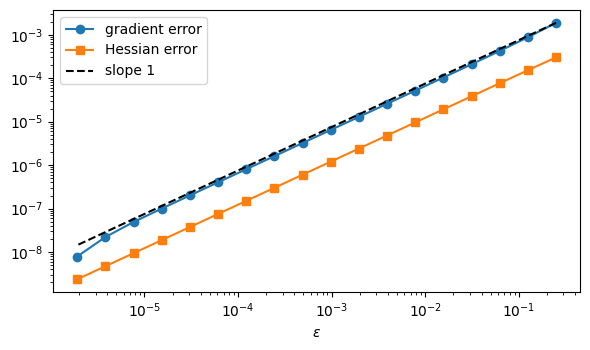

In [3]:
m0 = prior.mean.copy()
eps, err_grad, err_H = hm.parameter2QoiMapVerify(p2q, m0, verbose=False)
slope_g = np.polyfit(np.log(eps[:6]), np.log(err_grad[:6]), 1)[0]
slope_H = np.polyfit(np.log(eps[:6]), np.log(err_H[:6]), 1)[0]
print("first-order slopes: gradient %.3f, Hessian %.3f" % (slope_g, slope_H))

plt.figure(figsize=(6, 3.6))
plt.loglog(eps, err_grad, "-o", label="gradient error")
plt.loglog(eps, err_H, "-s", label="Hessian error")
plt.loglog(eps, err_grad[0] * eps / eps[0], "k--", label="slope 1")
plt.xlabel(r"$\varepsilon$"); plt.legend(); plt.tight_layout()
plt.show()

## 4. A quadratic model, with moments in closed form

Expand $\mathcal{Q}$ to second order about the mean $\bar m$ of the Gaussian. Under
$m\sim\mathcal{N}(\bar m, \mathcal{C})$ the moments of that model need no sampling at all:

$$\mathbb{E}[\mathcal{Q}_2] = \bar q + \tfrac12\sum_i d_i,\qquad
\mathrm{Var}[\mathcal{Q}_2] = g^{\!\top}\mathcal{C}g + \tfrac12\sum_i d_i^2,$$

where $d_i$ are the eigenvalues of the QoI Hessian preconditioned by the covariance. Those come
from a randomized generalized eigensolver, so the cost is a few dozen Hessian actions, and the
spectrum itself is the interesting object: it says how many directions of the parameter the
prediction actually responds to.

Q at the prior mean: 1.034004
                         mean          std
Taylor order 1       1.034004     0.193146
Taylor order 2       1.054953     0.195750


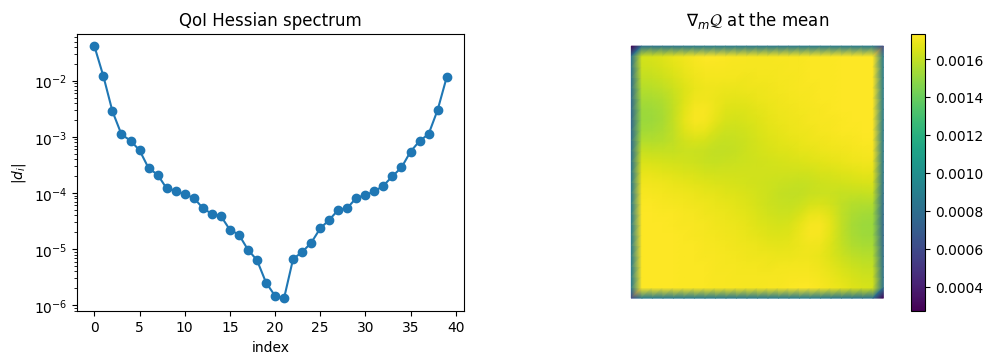

In [4]:
hm.parRandom.set_seed(2026)
k = 40
Omega = hm.MultiVector(prior.mean, k)
hm.parRandom.normal_multivector(1.0, Omega)

taylor = hm.TaylorApproximationQoi(p2q, prior)
d, U = taylor.computeLowRankFactorization(Omega, k=k)

print("Q at the prior mean: %.6f" % taylor.q_bar)
print("%-16s %12s %12s" % ("", "mean", "std"))
for order in (1, 2):
    print("%-16s %12.6f %12.6f"
          % ("Taylor order %d" % order, taylor.expectedValue(order),
             np.sqrt(taylor.variance(order))))

plt.figure(figsize=(11, 3.6))
plt.subplot(121)
plt.semilogy(np.abs(d), "o-")
plt.xlabel("index"); plt.ylabel("$|d_i|$"); plt.title("QoI Hessian spectrum")
nb.plot(Vm, taylor.g_bar, subplot_loc=122, mytitle=r"$\nabla_m \mathcal{Q}$ at the mean")
plt.show()

## 5. Monte Carlo on the difference

The quadratic model is cheap and biased. Used as a control variate it stops being biased:

$$\mathbb{E}[\mathcal{Q}] = \mathbb{E}[\mathcal{Q}_2]
 + \mathbb{E}[\mathcal{Q} - \mathcal{Q}_2] \approx
 \mathbb{E}[\mathcal{Q}_2] + \frac1N\sum_i \big(\mathcal{Q}(m_i) - \mathcal{Q}_2(m_i)\big),$$

with the first term known in closed form. What is sampled is the *difference*, whose spread is
small whenever the map is nearly quadratic, and the same number of PDE solves then buys a far
smaller error bar.

                             estimate    std error
plain Monte Carlo            1.043051     1.10e-02
with control variate         1.055208     3.20e-04

sample std: Q 0.1910, Q - Q_2 0.0056
variance reduction factor 1185, so about 1185x fewer solves for the same error


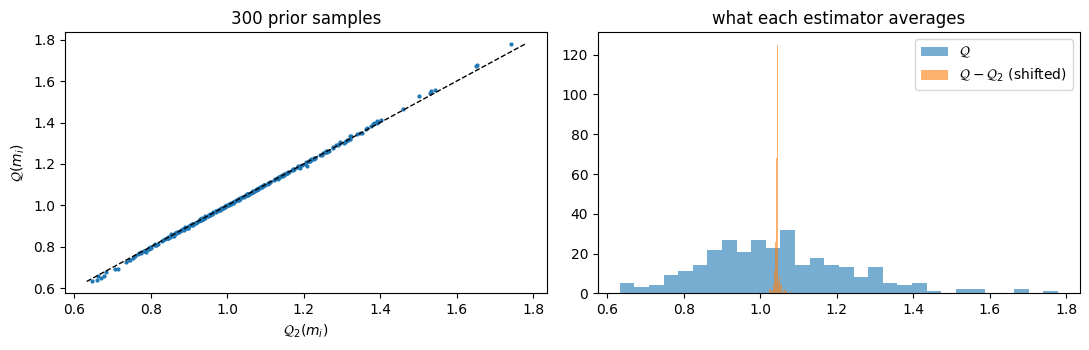

In [5]:
res = hm.varianceReductionMC(prior, p2q, taylor, 300, order=2)

print("%-24s %12s %12s" % ("", "estimate", "std error"))
print("%-24s %12.6f %12.2e" % ("plain Monte Carlo", res["mc_mean"], res["mc_stderr"]))
print("%-24s %12.6f %12.2e" % ("with control variate", res["reduced_mean"], res["reduced_stderr"]))
print()
print("sample std: Q %.4f, Q - Q_2 %.4f" % (res["sd_q"], res["sd_diff"]))
print("variance reduction factor %.0f, so about %.0fx fewer solves for the same error"
      % (res["variance_reduction"], res["variance_reduction"]))

q, qt = res["samples_q"], res["samples_taylor"]
plt.figure(figsize=(11, 3.6))
plt.subplot(121)
plt.plot(qt, q, ".", ms=4)
lo, hi = min(q.min(), qt.min()), max(q.max(), qt.max())
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel(r"$\mathcal{Q}_2(m_i)$"); plt.ylabel(r"$\mathcal{Q}(m_i)$"); plt.title("300 prior samples")
plt.subplot(122)
plt.hist(q, bins=30, alpha=0.6, label=r"$\mathcal{Q}$")
plt.hist(q - qt + q.mean(), bins=30, alpha=0.6, label=r"$\mathcal{Q}-\mathcal{Q}_2$ (shifted)")
plt.legend(); plt.title("what each estimator averages")
plt.tight_layout()
plt.show()

## 6. The same question after the data

Everything above used the prior. Observations of the pressure change the distribution on $m$,
and the prediction should follow. The Laplace approximation of the posterior is a Gaussian with
the MAP point as its mean, so it can play exactly the role the prior played: the Taylor model is
built at the MAP, the eigenvalues are of the QoI Hessian preconditioned by the *posterior*
covariance, and the control variate works the same way.

MAP: 8 Newton iterations, 98 CG iterations, relative error in m 0.528
Q at the truth: 1.049284


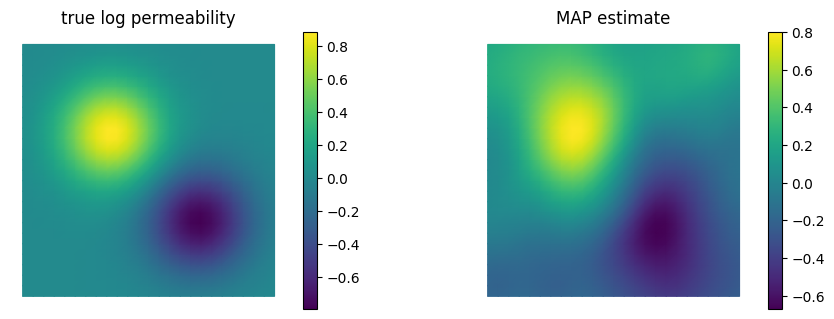

In [6]:
mtrue = Vm.project(lambda z: 0.9 * np.exp(-25.0 * ((z[0] - 0.35) ** 2 + (z[1] - 0.65) ** 2))
                   - 0.8 * np.exp(-25.0 * ((z[0] - 0.7) ** 2 + (z[1] - 0.3) ** 2)))
utrue = pde.generate_state()
pde.solveFwd(utrue, [utrue, mtrue, None])
q_true = p2q.eval([utrue, mtrue, None])

rng = np.random.default_rng(11)
targets = np.column_stack((rng.uniform(0.03, 0.97, 200), rng.uniform(0.03, 0.97, 200)))
B = hm.assemblePointwiseObservation(Vu, targets)
data = B.createVecLeft()
B.mult(utrue, data)
noise_std = 0.005 * data.norm("linf")
hm.parRandom.set_seed(8)
B.perturb(data, noise_std)

model = hm.Model(pde, prior, hm.DiscreteStateObservation(B, data, noise_std ** 2))
params = hm.ReducedSpaceNewtonCG_ParameterList()
params["rel_tolerance"] = 1e-9
params["max_iter"] = 25
params["print_level"] = -1
newton = hm.ReducedSpaceNewtonCG(model, params)
x = newton.solve([None, prior.mean.copy(), None])
err = mtrue.copy().axpy(-1.0, x[PARAMETER]).norm("l2") / mtrue.norm("l2")
print("MAP: %d Newton iterations, %d CG iterations, relative error in m %.3f"
      % (newton.it, newton.total_cg_iter, err))
print("Q at the truth: %.6f" % q_true)

plt.figure(figsize=(11, 3.6))
nb.plot(Vm, mtrue, subplot_loc=121, mytitle="true log permeability")
nb.plot(Vm, x[PARAMETER], subplot_loc=122, mytitle="MAP estimate")
plt.show()

In [7]:
model.setPointForHessianEvaluations(x, gauss_newton_approx=False)
Hmisfit = hm.ReducedHessian(model, misfit_only=True)
kp = 60
Om = hm.MultiVector(x[PARAMETER], kp + 10)
hm.parRandom.normal_multivector(1.0, Om)
dpost, Upost = hm.doublePassG(Hmisfit, prior.R, prior.Rsolver, Om, kp)
post = hm.GaussianLRPosterior(prior, dpost, Upost, mean=x[PARAMETER])

Om2 = hm.MultiVector(x[PARAMETER], 40)
hm.parRandom.normal_multivector(1.0, Om2)
taylor_post = hm.TaylorApproximationQoi(p2q, post)      # the posterior in the prior's place
d2, U2 = taylor_post.computeLowRankFactorization(Om2, k=40)

print("%-22s %10s %10s" % ("", "mean", "std"))
print("%-22s %10.4f %10.4f" % ("prior prediction", taylor.expectedValue(2), np.sqrt(taylor.variance(2))))
print("%-22s %10.4f %10.4f" % ("posterior prediction", taylor_post.expectedValue(2),
                               np.sqrt(taylor_post.variance(2))))
print("%-22s %10.4f" % ("truth", q_true))

                             mean        std
prior prediction           1.0550     0.1958
posterior prediction       1.0736     0.0830
truth                      1.0493


The prediction tightens by a factor of two and a half although the parameter itself is
recovered only in part, with a relative error above one half: the quantity of interest leans on
a few directions of the parameter, and the data informs those.

The control variate is written out here rather than called, because under the posterior the
samples come from `post.sample()`: draw, solve, evaluate, and average the difference against the
model's analytic mean. It is the same three lines `varianceReductionMC` runs for a prior.

posterior mean of Q: plain MC 1.078857 (+- 4.7e-03), with control variate 1.073698 (+- 4.3e-05)
variance reduction factor 11684


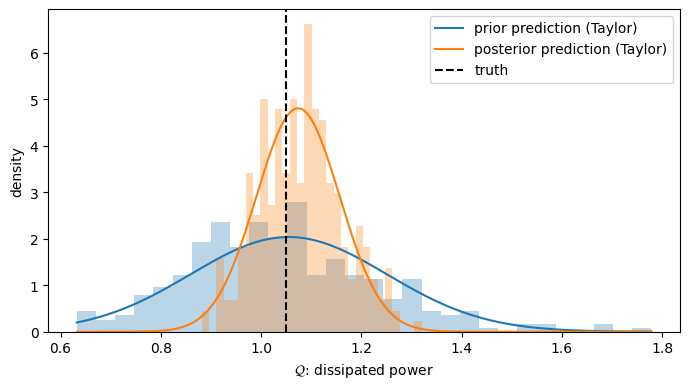

In [8]:
N = 300
qp = np.zeros(N)
qp_taylor = np.zeros(N)
for i in range(N):
    ms = post.sample()
    qp[i] = p2q.reduced_eval(ms)
    qp_taylor[i] = taylor_post.eval(ms)

diff = qp - qp_taylor
mean_cv = taylor_post.expectedValue(2) + diff.mean()
print("posterior mean of Q: plain MC %.6f (+- %.1e), with control variate %.6f (+- %.1e)"
      % (qp.mean(), qp.std(ddof=1) / np.sqrt(N), mean_cv, diff.std(ddof=1) / np.sqrt(N)))
print("variance reduction factor %.0f" % ((qp.std(ddof=1) / diff.std(ddof=1)) ** 2))

grid = np.linspace(min(q.min(), qp.min()), max(q.max(), qp.max()), 400)
gauss = lambda z, mu, sd: np.exp(-0.5 * ((z - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))
plt.figure(figsize=(7, 4))
plt.hist(q, bins=30, density=True, alpha=0.3, color="C0")
plt.hist(qp, bins=30, density=True, alpha=0.3, color="C1")
plt.plot(grid, gauss(grid, taylor.expectedValue(2), np.sqrt(taylor.variance(2))), "C0",
         label="prior prediction (Taylor)")
plt.plot(grid, gauss(grid, taylor_post.expectedValue(2), np.sqrt(taylor_post.variance(2))), "C1",
         label="posterior prediction (Taylor)")
plt.axvline(q_true, color="k", ls="--", label="truth")
plt.xlabel(r"$\mathcal{Q}$: dissipated power"); plt.ylabel("density")
plt.legend(); plt.tight_layout()
plt.show()

## What to take from this

- A quantity of interest is a density, like the residual: `VariationalQoi` differentiates it, so
  the reduced map $m\mapsto\mathcal{Q}$ comes with an adjoint gradient and a matrix-free Hessian,
  and `parameter2QoiMapVerify` checks both.
- The **eigenvalues of the covariance-preconditioned QoI Hessian** are the whole cost of a
  second-order Taylor model, and they give its mean and variance in closed form. Their decay is
  the statement that a scalar prediction depends on few directions of an infinite-dimensional
  parameter.
- As a **control variate** the same model removes its own bias: sampling
  $\mathcal{Q}-\mathcal{Q}_2$ instead of $\mathcal{Q}$ cut the variance by three orders of
  magnitude here, and the analytic term it is added back to costs nothing.
- The **Laplace posterior substitutes for the prior** everywhere in this pipeline, which is what
  makes a prediction after data as cheap as one before it.
- Report both estimates. The Taylor moments alone are a model of the map, not the map; the
  corrected Monte Carlo estimate with its standard error is the honest number, and the observed
  variance reduction factor says how much the model was worth.

`applications/forward_uq/model_subsurf_effperm.py` is this problem as a driver, with ParaView
output and the samples written out; `docs/source/guide/forward_uq.rst` is the reference for the
interface.